In [30]:
import random
from collections import deque
from pathlib import Path

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output
from gymnasium import ObservationWrapper
from gymnasium.spaces import Box
from gymnasium.wrappers import FrameStackObservation
import cv2


In [31]:
class ResizeObservation(ObservationWrapper):
    def __init__(self, env, shape=(84, 84)):
        super().__init__(env)
        self.shape = shape

        self.observation_space = Box(
            low=0,
            high=255,
            shape=self.shape,
            dtype=np.uint8,
        )

    def observation(self, obs):
        # obs should be grayscale already: shape (210, 160)
        obs = cv2.resize(obs, self.shape, interpolation=cv2.INTER_AREA)
        return obs.astype(np.uint8)

In [32]:
class ReplayBuffer:
    def __init__(self, capacity, device):
        self.buffer = deque(maxlen=capacity)
        self.device = device

    def add(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)

        obs = torch.tensor(np.array(obs), dtype=torch.float32, device=self.device) / 255.0
        next_obs = torch.tensor(np.array(next_obs), dtype=torch.float32, device=self.device) / 255.0

        actions = torch.tensor(actions, dtype=torch.long, device=self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        dones = torch.tensor(dones, dtype=torch.float32, device=self.device)

        return obs, actions, rewards, next_obs, dones

    def __len__(self):
        return len(self.buffer)

In [33]:
class DQN(nn.Module):
    def __init__(self, obs_shape, n_actions):
        super().__init__()
        input_dim = int(np.prod(obs_shape))

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [34]:
class Agent:
    def __init__(self, obs_shape, n_actions, device, gamma=0.99, lr=1e-4):
        self.device = device
        self.n_actions = n_actions
        self.gamma = gamma

        self.q_net = DQN(obs_shape, n_actions).to(device)
        self.target_net = DQN(obs_shape, n_actions).to(device)

        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)

    def select_action(self, obs, epsilon, action_space):
        if random.random() < epsilon:
            return action_space.sample()

        obs_t = torch.tensor(obs, dtype=torch.float32, device=self.device)
        obs_t = obs_t.unsqueeze(0) / 255.0

        with torch.no_grad():
            q_values = self.q_net(obs_t)

        return q_values.argmax(dim=1).item()

    def learn(self, batch):
        obs, actions, rewards, next_obs, dones = batch

        q_values = self.q_net(obs)
        action_q_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = self.target_net(next_obs)
            max_next_q_values = next_q_values.max(dim=1).values
            targets = rewards + self.gamma * max_next_q_values * (1 - dones)

        loss = F.mse_loss(action_q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

In [35]:
def evaluate(agent, episodes=5, max_steps=5000):
    env, obs, info = make_env(visualize=True)

    for episode in range(episodes):
        obs, info = env.reset()

        # launch ball at start
        obs, reward, terminated, truncated, info = env.step(1)  # FIRE

        done = False
        total_reward = 0
        lives = info.get("lives", 0)

        for step in range(max_steps):
            action = agent.select_action(
                obs,
                epsilon=0.0,
                action_space=env.action_space,
            )

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            done = terminated or truncated

            new_lives = info.get("lives", lives)

            # If life was lost, relaunch
            if new_lives < lives and not done:
                obs, fire_reward, terminated, truncated, info = env.step(1)  # FIRE
                total_reward += fire_reward
                done = terminated or truncated

            lives = info.get("lives", new_lives)

            if done:
                break

        print(f"Episode {episode + 1}: {total_reward}")

In [36]:
def make_env(visualize=False, seed=42):
    gym.register_envs(ale_py)

    env = gym.make(
        "ALE/Breakout-v5",
        render_mode="human" if visualize else None,
        obs_type="grayscale",
        frameskip=4,
    )

    env = ResizeObservation(env, shape=(84, 84))
    env = FrameStackObservation(env, stack_size=4)

    obs, info = env.reset(seed=seed)
    return env, obs, info

In [37]:
def plot_training(episode_rewards, losses):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards)
    plt.title("Episode Reward")
    plt.xlabel("Episode")
    plt.ylabel("Reward")

    plt.subplot(1, 2, 2)
    plt.plot(losses)
    plt.title("DQN Loss")
    plt.xlabel("Gradient update")
    plt.ylabel("MSE loss")

    plt.tight_layout()
    plt.show()

In [38]:
def save_checkpoint(path, agent, epsilon, step, episode, episode_rewards, losses):
    checkpoint = {
        "q_net_state_dict": agent.q_net.state_dict(),
        "optimizer_state_dict": agent.optimizer.state_dict(),
        "epsilon": epsilon,
        "step": step,
        "episode": episode,
        "episode_rewards": episode_rewards,
        "losses": losses,
        "target_net_state_dict": agent.target_net.state_dict()
    }

    torch.save(checkpoint, path)
    print(f"Saved checkpoint to {path}")

In [39]:
def load_checkpoint(path, agent, device):
    checkpoint = torch.load(path, map_location=device)

    agent.q_net.load_state_dict(checkpoint["q_net_state_dict"])
    agent.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    agent.target_net.load_state_dict(checkpoint["target_net_state_dict"])

    print(f"Loaded checkpoint from {path}")
    
    return {
        "epsilon": checkpoint["epsilon"],
        "step": checkpoint["step"],
        "episode": checkpoint["episode"],
        "episode_rewards": checkpoint["episode_rewards"],
        "losses": checkpoint["losses"],
    }

In [40]:
def train(
    agent,
    env,
    replay_buffer,
    num_steps=50_000,
    batch_size=32,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.999995,
    save_every=5_000,
    checkpoint_path="breakout_dqn_checkpoint.pt",
    start_step=0,
    start_episode=0,
    target_update_every=1000,
    episode_rewards=None,
    losses=None,
):
    obs, info = env.reset()
    obs, reward, terminated, truncated, info = env.step(1)  # FIRE
    lives = info.get("lives", 0)

    episode_reward = 0
    episode = start_episode
    update_count = 0

    if episode_rewards is None:
        episode_rewards = []

    if losses is None:
        losses = []

    for local_step in range(num_steps):
        global_step = start_step + local_step

        action = agent.select_action(obs, epsilon, env.action_space)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        new_lives = info.get("lives", lives)

        if new_lives < lives and not done:
            next_obs, fire_reward, terminated, truncated, info = env.step(1)
            reward += fire_reward
            done = terminated or truncated

        lives = info.get("lives", new_lives)

        replay_buffer.add(obs, action, reward, next_obs, done)
        episode_reward += reward

        loss = None

        if len(replay_buffer) >= batch_size:
            batch = replay_buffer.sample(batch_size)
            loss = agent.learn(batch)
            losses.append(loss)
            update_count += 1

            if update_count % target_update_every == 0:
                agent.update_target_network

        if done:
            episode_rewards.append(episode_reward)
            episode += 1
            episode_reward = 0

            obs, info = env.reset()
            obs, reward, terminated, truncated, info = env.step(1)
            lives = info.get("lives", 0)
        else:
            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if local_step % 500 == 0:
            clear_output(wait=True)
            print(f"Global step: {global_step}")
            print(f"Local step: {local_step}")
            print(f"Episode: {episode}")
            print(f"Gradient updates this run: {update_count}")
            print(f"Epsilon: {epsilon:.3f}")
            print(f"Replay buffer size: {len(replay_buffer)}")

            if loss is not None:
                print(f"Latest loss: {loss:.5f}")

            if episode_rewards:
                print(f"Latest episode reward: {episode_rewards[-1]}")

            plot_training(episode_rewards, losses)

        if global_step > 0 and global_step % save_every == 0:
            save_checkpoint(
                checkpoint_path,
                agent,
                epsilon,
                global_step,
                episode,
                episode_rewards,
                losses,
            )

    final_step = start_step + num_steps

    save_checkpoint(
        checkpoint_path,
        agent,
        epsilon,
        final_step,
        episode,
        episode_rewards,
        losses,
    )

    return agent, epsilon, episode_rewards, losses

In [19]:
env, obs, info = make_env(visualize=False, seed=42)

CHECKPOINT_PATH = "breakout_dqn_checkpoint.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"
agent = Agent(obs.shape, env.action_space.n, device)
replay_buffer = ReplayBuffer(capacity=5000, device=device)
epsilon = 1.0

In [20]:
print(obs.shape)

(4, 84, 84)


In [16]:

if Path(CHECKPOINT_PATH).exists():
    checkpoint = load_checkpoint(
        CHECKPOINT_PATH,
        agent,
        device,
    )

    epsilon = checkpoint["epsilon"]

    print(f"Resuming from step {checkpoint['step']}")

else:
    print("No checkpoint found. Starting fresh.")

No checkpoint found. Starting fresh.


Global step: 54499
Local step: 49500
Episode: 319
Gradient updates this run: 49470
Epsilon: 0.761
Replay buffer size: 5000
Latest loss: 0.02872
Latest episode reward: 4.0


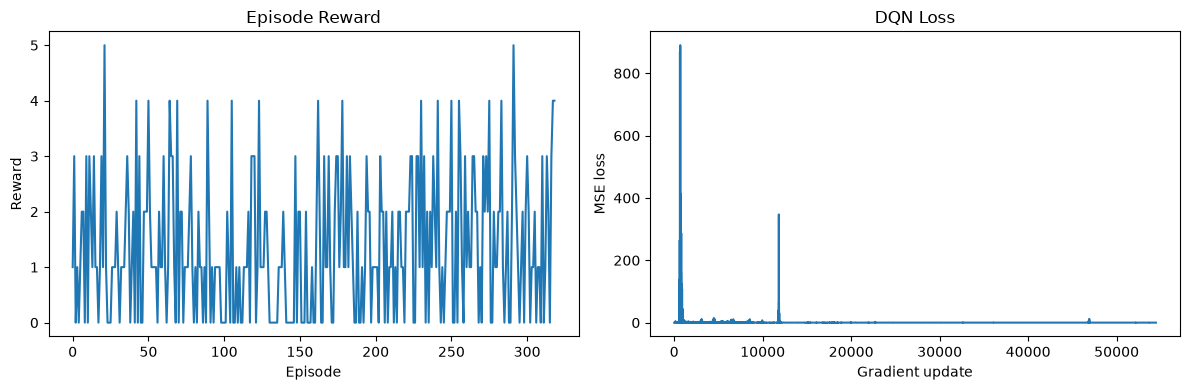

Saved checkpoint to breakout_dqn_checkpoint.pt


In [19]:
agent, epsilon, episode_rewards, losses = train(
    agent,
    env,
    replay_buffer,
    num_steps=50_000,
    epsilon=checkpoint["epsilon"],
    start_step=checkpoint["step"],
    start_episode=checkpoint["episode"],
    episode_rewards=checkpoint["episode_rewards"],
    losses=checkpoint["losses"],
)

In [20]:
evaluate(agent, episodes=5)

Episode 1: 1.0
Episode 2: 3.0
Episode 3: 3.0
Episode 4: 1.0
Episode 5: 3.0
